[Project: Breast Cancer Prediction AI]
I built a machine learning model to predict breast cancer malignancy using the Random Forest algorithm. The model analyzed 30 digital features of cell nuclei and achieved an accuracy of 96.49%. Through feature importance analysis, the AI identified that the 'worst area' of the cells is the most critical indicator of cancer. This project demonstrates my ability to combine medical domain knowledge with data science to solve real healthcare problems.

In [3]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# 1. 乳がんデータセットの読み込み
cancer_data = load_breast_cancer()

# 2. データをPandas DataFrameに変換
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# 3. 目的変数（target）の追加（0=良性、1=悪性に反転して直感的なフラグにする）
df['target'] = 1 - cancer_data.target

# 4. データセットの先頭5行を表示して確認
pd.set_option('display.max_columns', None)
print("▼ 乳がん細胞のデータセット（先頭5行）")
print(df.head())

▼ 乳がん細胞のデータセット（先頭5行）
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  radius error  texture error  perimeter error

▼ モデルの予測精度（Accuracy）: 96.49%



/tmp/ipykernel_277/1894160448.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


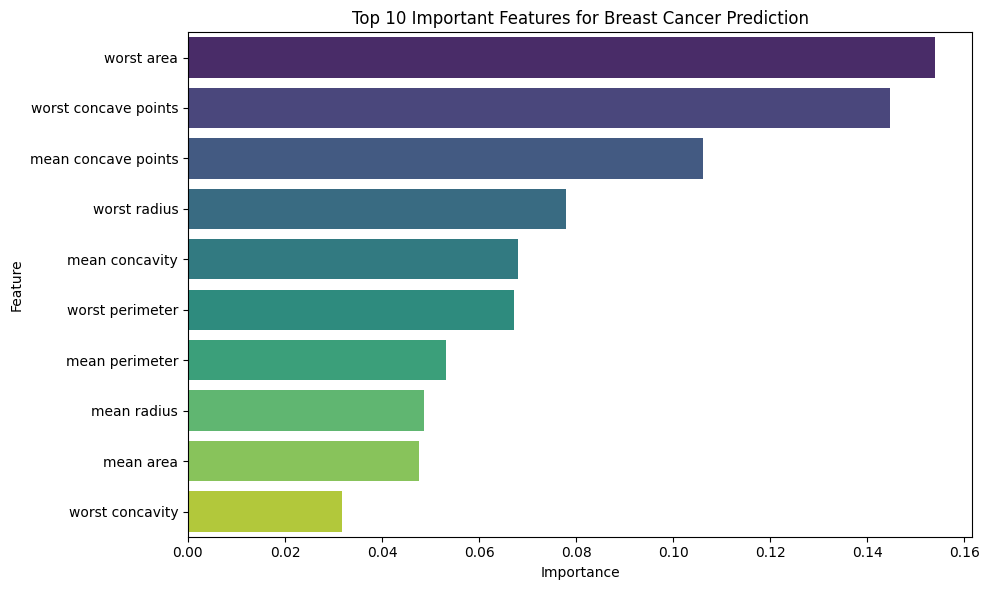

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 特徴量（X）と目的変数（y）の分割
X = df.drop('target', axis=1)
y = df['target']

# 2. 学習用データ（80%）とテスト用データ（20%）に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. ランダムフォレストモデルの構築と学習
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. テストデータでの予測と精度の算出
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"▼ モデルの予測精度（Accuracy）: {accuracy * 100:.2f}%\n")

# 5. 特徴量重要度（Feature Importance）の算出と可視化
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 10 Important Features for Breast Cancer Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()